# MLPs por dimensión — TFG ML Lattice Cryptanalysis

**Hipótesis:** Entrenar un MLP separado por cada dimensión `d` mejora el R² del RHF respecto
al MLP global, replicando la mejora ya observada con XGBoost en `dim_models.ipynb`.

**Referencia:** Con XGBoost y split corregido por base (sin fuga), el R² global del RHF es ~0.74
y mejora per-dim hasta ~0.97–0.99 para d≥50. Con MLP la mejora per-dim es visible para d≤80
pero el modelo colapsa (R² muy negativo) para d≥150 en RHF y log_norm_b1, lo que indica
sobreajuste severo cuando el conjunto de test contiene bases genuinamente nuevas.

**Dataset:** `lattice_dataset_v2.csv` — 224 000 filas, 4 tipos de retículo, d ∈ {10,20,30,50,80,100,120,150,200}.

**Arquitectura:** `ConditionedMLP` con capas `[256, 128, 64]` (ampliada respecto a v1 por tener 29 features de entrada).

In [10]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
import time
import os

from split_utils import reconstruct_base_id, load_test_base_ids

warnings.filterwarnings('ignore')
os.makedirs('graphs', exist_ok=True)

In [11]:
df = pd.read_csv('lattice_dataset_v2.csv')
# base_id canónico ANTES de get_dummies → se arrastra a df_enc
df['base_id'] = reconstruct_base_id(df)
print(f"Shape: {df.shape}")
print(df['d'].value_counts().sort_index())
print(df['lattice_type'].value_counts())

# One-hot encoding de lattice_type
df_enc = pd.get_dummies(df, columns=['lattice_type'], drop_first=False)

Shape: (224000, 31)
d
10     32000
20     32000
30     32000
50     32000
80     32000
100    16000
120    16000
150    16000
200    16000
Name: count, dtype: int64
lattice_type
uniform     56000
gaussian    56000
sparse      56000
qary        56000
Name: count, dtype: int64


In [12]:
# ── Reproducibilidad ──────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

# ── Hiperparámetros ───────────────────────────────────────────────────────
TARGETS      = ['target_log_orth_defect', 'target_log_norm_b1', 'target_rhf']
HIDDEN_DIMS  = [256, 128, 64]
DROPOUT_P    = 0.1
BATCH_SIZE   = 512
EPOCHS       = 300
LR           = 1e-3
WEIGHT_DECAY = 1e-4

# ── Features ──────────────────────────────────────────────────────────────
FEATURE_COLS_BASE = [
    'log_det', 'norm_mean', 'norm_std', 'norm_max', 'norm_min', 'norm_ratio',
    'gso_mean', 'gso_std', 'gso_max', 'gso_min', 'gso_ratio', 'gso_slope', 'gso_res_std',
    'log_orth_defect', 'gram_off_diag_mean', 'gram_off_diag_max',
    'log_cond_num', 'mu_mean', 'mu_max', 'mu_frac_gt_05', 'std_B',
    'profile_mass', 'profile_entropy', 'profile_adjacency',
    'delta'
]
lt_cols = [c for c in df_enc.columns if c.startswith('lattice_type_')]
FEATURE_COLS_PER_DIM = FEATURE_COLS_BASE + lt_cols   # 29 features, sin 'd'
FEATURE_COLS_GLOBAL  = FEATURE_COLS_BASE + ['d'] + lt_cols  # 30 features

print(f"Features per-dim : {len(FEATURE_COLS_PER_DIM)}  ({FEATURE_COLS_PER_DIM})")
print(f"Features global  : {len(FEATURE_COLS_GLOBAL)}")

# ── Validación de base_id canónico ────────────────────────────────────────
_counts = df_enc.groupby('base_id').size()
assert (_counts == 4).all(), "Algunas bases no tienen exactamente 4 filas"
_feat_check = [c for c in FEATURE_COLS_BASE if c != 'delta']
_max_var = df_enc.groupby('base_id')[_feat_check].var().max().max()
assert _max_var < 1e-10, f"Features no son constantes dentro de algunas bases (var máx = {_max_var:.2e})"
print(f"Aserción OK: {df_enc['base_id'].nunique()} bases únicas, todas con 4 filas y features constantes.")

Dispositivo: cuda
Features per-dim : 29  (['log_det', 'norm_mean', 'norm_std', 'norm_max', 'norm_min', 'norm_ratio', 'gso_mean', 'gso_std', 'gso_max', 'gso_min', 'gso_ratio', 'gso_slope', 'gso_res_std', 'log_orth_defect', 'gram_off_diag_mean', 'gram_off_diag_max', 'log_cond_num', 'mu_mean', 'mu_max', 'mu_frac_gt_05', 'std_B', 'profile_mass', 'profile_entropy', 'profile_adjacency', 'delta', 'lattice_type_gaussian', 'lattice_type_qary', 'lattice_type_sparse', 'lattice_type_uniform'])
Features global  : 30
Aserción OK: 56000 bases únicas, todas con 4 filas y features constantes.


In [13]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  ARQUITECTURA: ConditionedMLP                                   ║
# ╚══════════════════════════════════════════════════════════════════╝
# Reutilizada de models_firstaproach.ipynb.
# Patrón: Linear → BatchNorm → GELU → Dropout en cada capa oculta.
# BatchNorm estabiliza gradientes para features con escalas muy distintas.
# GELU evita neuronas muertas y es preferible a ReLU en regresión continua.

class ConditionedMLP(nn.Module):
    def __init__(self, n_features: int, hidden_dims: list, dropout_p: float = 0.1):
        super().__init__()
        layers = []
        in_dim = n_features
        for out_dim in hidden_dims:
            layers += [
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.GELU(),
                nn.Dropout(p=dropout_p),
            ]
            in_dim = out_dim
        layers.append(nn.Linear(in_dim, 1))
        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
        last_linear = [m for m in self.modules() if isinstance(m, nn.Linear)][-1]
        nn.init.xavier_normal_(last_linear.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


# Verificar con las dimensiones de entrada de v2
n_feat_per_dim = len(FEATURE_COLS_PER_DIM)
_tmp = ConditionedMLP(n_feat_per_dim, HIDDEN_DIMS, DROPOUT_P)
total_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(_tmp)
print(f"\nParámetros entrenables (per-dim): {total_params:,}")
del _tmp

ConditionedMLP(
  (network): Sequential(
    (0): Linear(in_features=29, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Parámetros entrenables (per-dim): 49,793


In [14]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  HELPERS: train_mlp() y train_evaluate_mlp()                    ║
# ╚══════════════════════════════════════════════════════════════════╝

def train_mlp(X_tr: np.ndarray, X_te: np.ndarray,
              y_tr: np.ndarray, y_te: np.ndarray,
              n_features: int, label: str = '') -> tuple:
    """
    Entrena un ConditionedMLP y devuelve (best_r2, best_mae, model).
    X_tr/X_te ya están escalados (StandardScaler aplicado por el caller).
    Imprime progreso cada 50 épocas.
    """
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)
    y_te_t = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)

    tr_loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(SEED)
    )
    te_loader = DataLoader(
        TensorDataset(X_te_t, y_te_t),
        batch_size=BATCH_SIZE, shuffle=False
    )

    model     = ConditionedMLP(n_features, HIDDEN_DIMS, DROPOUT_P).to(DEVICE)
    criterion = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

    best_r2    = -np.inf
    best_mae   = np.inf
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        ep_loss = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            ep_loss += loss.item() * len(xb)
        scheduler.step()

        if epoch % 50 == 0 or epoch == 1:
            model.eval()
            all_p, all_t = [], []
            with torch.no_grad():
                for xb, yb in te_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    all_p.append(model(xb).cpu().numpy())
                    all_t.append(yb.cpu().numpy())
            p_np = np.concatenate(all_p).ravel()
            t_np = np.concatenate(all_t).ravel()
            vr2  = r2_score(t_np, p_np)
            vmae = mean_absolute_error(t_np, p_np)
            avg_tr = ep_loss / len(tr_loader.dataset)
            lr_now = scheduler.get_last_lr()[0]
            print(f"  [{label}] Ep {epoch:>3}/{EPOCHS} | "
                  f"TrainL: {avg_tr:.4f} | R²: {vr2:.4f} | MAE: {vmae:.5f} | LR: {lr_now:.2e}")

            if vr2 > best_r2:
                best_r2    = vr2
                best_mae   = vmae
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return best_r2, best_mae, model


def train_evaluate_mlp(X_df: pd.DataFrame, y_series: pd.Series,
                       base_id: pd.Series, label: str = '') -> tuple:
    """
    Split canónico 80/20 por base (load_test_base_ids), escala, entrena y devuelve
    (best_r2, best_mae, model). base_id debe ser df['base_id'] (serie canónica).
    """
    X_raw = X_df.values.astype(np.float32)
    y_raw = y_series.values.astype(np.float32)

    test_ids_set = load_test_base_ids()
    is_test  = base_id.isin(test_ids_set).to_numpy()
    train_pos, test_pos = np.where(~is_test)[0], np.where(is_test)[0]

    assert not (set(base_id.iloc[train_pos]) & set(base_id.iloc[test_pos])), \
        f"FUGA: base_ids comunes en train y test ({label})"

    X_train_raw, X_test_raw = X_raw[train_pos], X_raw[test_pos]
    y_tr, y_te = y_raw[train_pos], y_raw[test_pos]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_te = scaler.transform(X_test_raw).astype(np.float32)

    n_features = X_tr.shape[1]
    r2, mae, model = train_mlp(X_tr, X_te, y_tr, y_te, n_features, label=label)
    print(f"  → {label} | Mejor R²={r2:.4f}  MAE={mae:.5f}")
    return r2, mae, model

## 1. Modelo global MLP (baseline)

Incluye `d` y `lattice_type` como features. Sirve como referencia directa frente al global XGBoost de `dim_models.ipynb`.

In [15]:
# Resultados XGBoost global de referencia (dim_models.ipynb, partición canónica)
# Actualizar tras re-ejecutar dim_models.ipynb con la partición canónica
XGBOOST_GLOBAL_RF = {
    'target_log_orth_defect': 0.9996,
    'target_log_norm_b1':     0.9777,
    'target_rhf':             0.7410,
}
XGBOOST_GLOBAL_GB = {
    'target_log_orth_defect': 0.9997,
    'target_log_norm_b1':     0.9768,
    'target_rhf':             0.7377,
}

global_mlp_results = {}
t0 = time.time()

for target in TARGETS:
    print(f"\n=== GLOBAL — {target} ===")
    r2, mae, _ = train_evaluate_mlp(
        df_enc[FEATURE_COLS_GLOBAL], df_enc[target],
        base_id=df_enc['base_id'],
        label=f'GLOBAL-{target}'
    )
    global_mlp_results[target] = {'r2': r2, 'mae': mae}

print(f"\nTiempo total modelos globales: {time.time()-t0:.1f}s")

print("\n" + "="*60)
print(f"  {'Target':<28} {'XGB-RF':>8} {'XGB-GB':>8} {'MLP':>8}")
print("  " + "-"*56)
for t in TARGETS:
    r2 = global_mlp_results[t]['r2']
    print(f"  {t:<28} {XGBOOST_GLOBAL_RF[t]:>8.4f} {XGBOOST_GLOBAL_GB[t]:>8.4f} {r2:>8.4f}")
print("="*60)


=== GLOBAL — target_log_orth_defect ===
  [GLOBAL-target_log_orth_defect] Ep   1/300 | TrainL: 61.2470 | R²: -0.2126 | MAE: 53.67120 | LR: 1.00e-03
  [GLOBAL-target_log_orth_defect] Ep  50/300 | TrainL: 4.2014 | R²: 0.9992 | MAE: 1.69989 | LR: 9.34e-04
  [GLOBAL-target_log_orth_defect] Ep 100/300 | TrainL: 3.3924 | R²: 0.9995 | MAE: 1.37313 | LR: 7.52e-04
  [GLOBAL-target_log_orth_defect] Ep 150/300 | TrainL: 3.1509 | R²: 0.9995 | MAE: 1.31727 | LR: 5.05e-04
  [GLOBAL-target_log_orth_defect] Ep 200/300 | TrainL: 3.0208 | R²: 0.9993 | MAE: 1.51211 | LR: 2.57e-04
  [GLOBAL-target_log_orth_defect] Ep 250/300 | TrainL: 2.9222 | R²: 0.9996 | MAE: 1.18741 | LR: 7.63e-05
  [GLOBAL-target_log_orth_defect] Ep 300/300 | TrainL: 2.9319 | R²: 0.9995 | MAE: 1.31739 | LR: 1.00e-05
  → GLOBAL-target_log_orth_defect | Mejor R²=0.9996  MAE=1.18741

=== GLOBAL — target_log_norm_b1 ===
  [GLOBAL-target_log_norm_b1] Ep   1/300 | TrainL: 0.3528 | R²: 0.9584 | MAE: 0.10581 | LR: 1.00e-03
  [GLOBAL-target_l

## 2. MLPs por dimensión

Para cada `d`, se filtra el dataset y se entrena un MLP **sin** `d` como feature.
Total: 9 dimensiones × 3 targets = **27 modelos**.

In [16]:
import json as _json
import os

# Cargar resultados XGBoost per-dim generados por dim_models.ipynb (partición canónica)
_xgb_path = 'models/per_dim/xgb_results.json'
if os.path.exists(_xgb_path):
    with open(_xgb_path) as _f:
        _xgb_data = _json.load(_f)
    XGBOOST_PERDIM_RF = {}
    XGBOOST_PERDIM_GB = {}
    for _d_str, _d_data in _xgb_data['per_dim'].items():
        _d = int(_d_str)
        for _t, _metrics in _d_data.items():
            XGBOOST_PERDIM_RF.setdefault(_t, {})[_d] = _metrics['RF']['r2']
            XGBOOST_PERDIM_GB.setdefault(_t, {})[_d] = _metrics['GB']['r2']
    print(f"Resultados XGBoost cargados desde {_xgb_path}")
else:
    print(f"AVISO: {_xgb_path} no encontrado. Ejecuta dim_models.ipynb primero.")
    print("Usando valores de referencia hardcodeados como fallback (partición canónica, pendiente re-ejecución).")
    XGBOOST_PERDIM_RF = {
        'target_log_orth_defect': {10:0.4496, 20:0.8251, 30:0.9413, 50:0.9908, 80:0.9981, 100:0.9990, 120:0.9996, 150:0.9998, 200:0.9999},
        'target_log_norm_b1':     {10:0.7482, 20:0.7853, 30:0.8472, 50:0.9329, 80:0.9622, 100:0.9712, 120:0.9795, 150:0.9760, 200:0.9683},
        'target_rhf':             {10:0.4871, 20:0.7110, 30:0.8693, 50:0.9702, 80:0.9904, 100:0.9942, 120:0.9966, 150:0.9969, 200:0.9975},
    }
    XGBOOST_PERDIM_GB = {
        'target_log_orth_defect': {10:0.4165, 20:0.8232, 30:0.9413, 50:0.9909, 80:0.9980, 100:0.9990, 120:0.9996, 150:0.9998, 200:0.9999},
        'target_log_norm_b1':     {10:0.7216, 20:0.7804, 30:0.8489, 50:0.9314, 80:0.9620, 100:0.9716, 120:0.9800, 150:0.9758, 200:0.9693},
        'target_rhf':             {10:0.4772, 20:0.7079, 30:0.8715, 50:0.9699, 80:0.9904, 100:0.9942, 120:0.9967, 150:0.9970, 200:0.9975},
    }

dimensions = sorted(df['d'].unique())
per_dim_mlp_results = {d: {} for d in dimensions}
per_dim_mlp_models  = {d: {} for d in dimensions}
t0 = time.time()

os.makedirs('models/mlp_per_dim', exist_ok=True)

for d in dimensions:
    df_d = df_enc[df_enc['d'] == d]
    print(f"\n{'='*60}")
    print(f"  d={d}  ({len(df_d)} filas, {df_d['base_id'].nunique()} bases)")
    print(f"{'='*60}")
    for target in TARGETS:
        r2, mae, _mlp = train_evaluate_mlp(
            df_d[FEATURE_COLS_PER_DIM], df_d[target],
            base_id=df_d['base_id'],
            label=f'd={d}-{target}'
        )
        per_dim_mlp_results[d][target] = {'r2': r2, 'mae': mae}
        fname = f'models/mlp_per_dim/{target}_d{d}.pt'
        torch.save(_mlp.state_dict(), fname)

print(f"\nTiempo total modelos per-dim: {time.time()-t0:.1f}s")
print(f"MLPs guardados en models/mlp_per_dim/ ({len(dimensions)*len(TARGETS)} archivos)")

Resultados XGBoost cargados desde models/per_dim/xgb_results.json

  d=10  (32000 filas, 8000 bases)
  [d=10-target_log_orth_defect] Ep   1/300 | TrainL: 0.6320 | R²: -0.0275 | MAE: 0.35123 | LR: 1.00e-03
  [d=10-target_log_orth_defect] Ep  50/300 | TrainL: 0.0698 | R²: 0.4005 | MAE: 0.26049 | LR: 9.34e-04
  [d=10-target_log_orth_defect] Ep 100/300 | TrainL: 0.0634 | R²: 0.4063 | MAE: 0.26088 | LR: 7.52e-04
  [d=10-target_log_orth_defect] Ep 150/300 | TrainL: 0.0609 | R²: 0.4014 | MAE: 0.26149 | LR: 5.05e-04
  [d=10-target_log_orth_defect] Ep 200/300 | TrainL: 0.0585 | R²: 0.3964 | MAE: 0.26383 | LR: 2.57e-04
  [d=10-target_log_orth_defect] Ep 250/300 | TrainL: 0.0571 | R²: 0.3943 | MAE: 0.26451 | LR: 7.63e-05
  [d=10-target_log_orth_defect] Ep 300/300 | TrainL: 0.0571 | R²: 0.3935 | MAE: 0.26426 | LR: 1.00e-05
  → d=10-target_log_orth_defect | Mejor R²=0.4063  MAE=0.26088
  [d=10-target_log_norm_b1] Ep   1/300 | TrainL: 0.5467 | R²: 0.0378 | MAE: 0.19818 | LR: 1.00e-03
  [d=10-target_

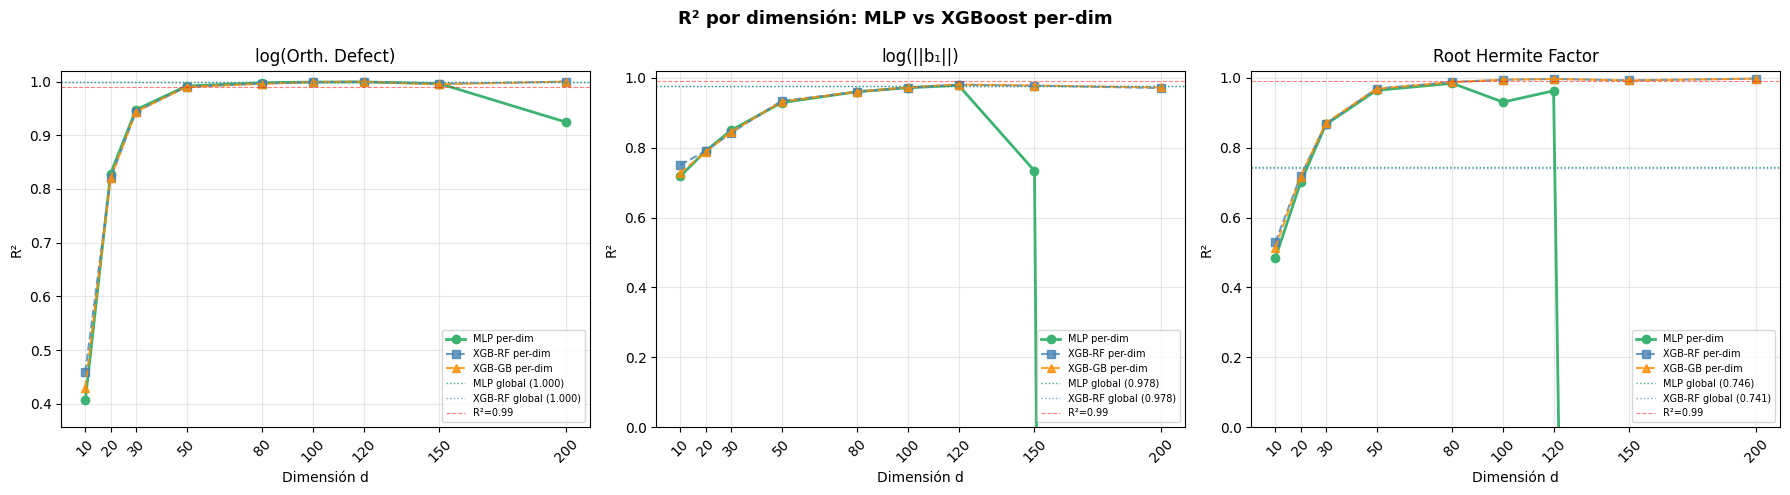

Figura guardada en graphs/dim_mlps_vs_xgboost.png


In [17]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  VISUALIZACIÓN: MLP per-dim vs XGBoost per-dim                  ║
# ╚══════════════════════════════════════════════════════════════════╝
TARGET_LABELS = {
    'target_log_orth_defect': 'log(Orth. Defect)',
    'target_log_norm_b1':     'log(||b₁||)',
    'target_rhf':             'Root Hermite Factor',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('R² por dimensión: MLP vs XGBoost per-dim', fontsize=13, fontweight='bold')

for ax, target in zip(axes, TARGETS):
    # R² per-dim
    mlp_r2s  = [per_dim_mlp_results[d][target]['r2'] for d in dimensions]
    xgb_rf   = [XGBOOST_PERDIM_RF[target][d]         for d in dimensions]
    xgb_gb   = [XGBOOST_PERDIM_GB[target][d]         for d in dimensions]

    # R² global
    g_mlp    = global_mlp_results[target]['r2']
    g_rf     = XGBOOST_GLOBAL_RF[target]
    g_gb     = XGBOOST_GLOBAL_GB[target]

    ax.plot(dimensions, mlp_r2s, 'o-',  color='mediumseagreen', linewidth=2,   label='MLP per-dim')
    ax.plot(dimensions, xgb_rf,  's--', color='steelblue',      linewidth=1.5, label='XGB-RF per-dim', alpha=0.8)
    ax.plot(dimensions, xgb_gb,  '^--', color='darkorange',     linewidth=1.5, label='XGB-GB per-dim', alpha=0.8)
    ax.axhline(g_mlp, color='mediumseagreen', linestyle=':',  linewidth=1,   label=f'MLP global ({g_mlp:.3f})')
    ax.axhline(g_rf,  color='steelblue',      linestyle=':',  linewidth=1,   label=f'XGB-RF global ({g_rf:.3f})', alpha=0.7)
    ax.axhline(0.99,  color='red',            linestyle='--', linewidth=0.8, label='R²=0.99', alpha=0.5)

    ax.set_title(TARGET_LABELS[target])
    ax.set_xlabel('Dimensión d')
    ax.set_ylabel('R²')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(max(0, min(mlp_r2s + xgb_rf + xgb_gb) - 0.05), 1.02)
    ax.set_xticks(dimensions)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('graphs/dim_mlps_vs_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada en graphs/dim_mlps_vs_xgboost.png")

## 3. Tabla resumen numérica

R² por dimensión y target para MLP, XGBoost-RF y XGBoost-GB (per-dim).

In [18]:
for target in TARGETS:
    print(f"\n{'='*65}")
    print(f"  {TARGET_LABELS[target]}")
    print(f"  {'d':>5} | {'XGB-RF':>8} | {'XGB-GB':>8} | {'MLP':>8} | {'ΔMLP-RF':>9}")
    print(f"  {'-'*60}")
    for d in dimensions:
        rf  = XGBOOST_PERDIM_RF[target][d]
        gb  = XGBOOST_PERDIM_GB[target][d]
        mlp = per_dim_mlp_results[d][target]['r2']
        delta = mlp - rf
        print(f"  {d:>5} | {rf:>8.4f} | {gb:>8.4f} | {mlp:>8.4f} | {delta:>+9.4f}")
    print(f"  {'='*60}")
    print(f"  GLOBAL| {XGBOOST_GLOBAL_RF[target]:>8.4f} | {XGBOOST_GLOBAL_GB[target]:>8.4f} | {global_mlp_results[target]['r2']:>8.4f} | {global_mlp_results[target]['r2']-XGBOOST_GLOBAL_RF[target]:>+9.4f}")

print("\n\nResumen MLP: ¿supera R²=0.96 para RHF en d≥50?")
target = 'target_rhf'
for d in dimensions:
    r2 = per_dim_mlp_results[d][target]['r2']
    flag = '✓' if r2 >= 0.96 else '✗'
    print(f"  d={d:>3}: R²={r2:.4f}  {flag}")


  log(Orth. Defect)
      d |   XGB-RF |   XGB-GB |      MLP |   ΔMLP-RF
  ------------------------------------------------------------
     10 |   0.4588 |   0.4290 |   0.4063 |   -0.0524
     20 |   0.8197 |   0.8200 |   0.8287 |   +0.0090
     30 |   0.9437 |   0.9439 |   0.9474 |   +0.0037
     50 |   0.9902 |   0.9900 |   0.9917 |   +0.0015
     80 |   0.9962 |   0.9958 |   0.9979 |   +0.0018
    100 |   0.9991 |   0.9991 |   0.9990 |   -0.0001
    120 |   0.9996 |   0.9996 |   0.9994 |   -0.0003
    150 |   0.9958 |   0.9949 |   0.9963 |   +0.0005
    200 |   0.9999 |   0.9999 |   0.9245 |   -0.0754
  GLOBAL|   0.9996 |   0.9997 |   0.9996 |   +0.0000

  log(||b₁||)
      d |   XGB-RF |   XGB-GB |      MLP |   ΔMLP-RF
  ------------------------------------------------------------
     10 |   0.7510 |   0.7279 |   0.7182 |   -0.0328
     20 |   0.7902 |   0.7871 |   0.7905 |   +0.0003
     30 |   0.8417 |   0.8448 |   0.8495 |   +0.0078
     50 |   0.9340 |   0.9318 |   0.9287 | 